# Phase 4 - Model Training

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [3]:
df = pd.read_csv("../data/cleaned/merged_data.csv")
print(df.shape)
df.head()

(1231, 16)


,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,risk_score,addiction_index,poor_sleep,high_usage
0,14,1,7,7.4,2.9,3.01,1.5,1,2,2,1,0,2.36,4.57,0,1
1,19,0,1,8.0,2.9,3.22,0.8,0,8,1,10,0,5.00,3.37,0,0
2,17,0,1,7.6,0.5,3.92,0.0,0,2,4,2,0,2.54,1.05,0,0
3,15,1,7,6.9,1.6,3.48,0.8,2,1,7,9,0,5.21,5.78,0,1
4,15,0,4,4.9,3.0,2.37,1.4,2,3,5,2,0,3.71,3.30,1,0


In [4]:
# Features and Target
X = df.drop(columns=['depression_label'])
y = df['depression_label']

print(X.shape, y.shape)
print(y.value_counts())

(1231, 15) (1231,)
depression_label
0    1200
1      31
Name: count, dtype: int64


### Train Test Split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(X_train.shape, X_test.shape)

(984, 15) (247, 15)


In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.fit_transform(X_test)

### Logistic Regression

In [7]:
# lr = LogisticRegression()
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.9676113360323887
              precision    recall  f1-score   support

           0       1.00      0.97      0.98       239
           1       0.50      1.00      0.67         8

    accuracy                           0.97       247
   macro avg       0.75      0.98      0.82       247
weighted avg       0.98      0.97      0.97       247



### Random Forest

In [8]:
# rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print('Random Forest Accuracy : ', accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy :  1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       239
           1       1.00      1.00      1.00         8

    accuracy                           1.00       247
   macro avg       1.00      1.00      1.00       247
weighted avg       1.00      1.00      1.00       247



### LR is more trustworthy here — 96.7% with balanced recall.

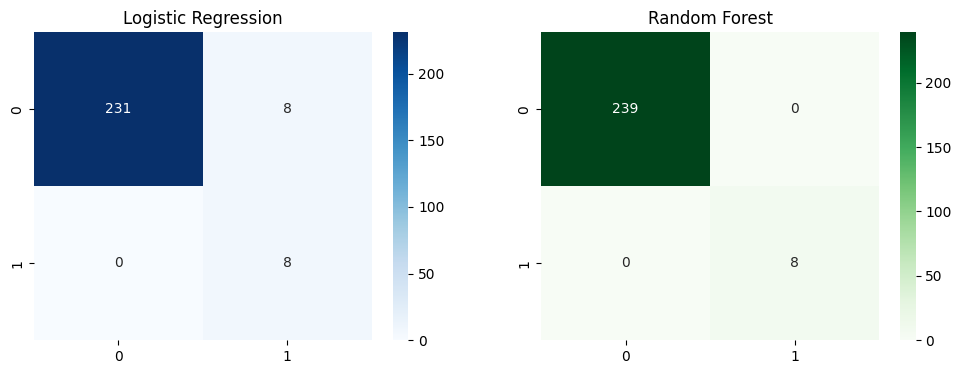

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
            ax=axes[0], cmap='Blues')
axes[0].set_title("Logistic Regression")

sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            ax=axes[1], cmap='Greens')
axes[1].set_title("Random Forest")

plt.savefig("../outputs/plots/confusion_matrix.png")
plt.show()

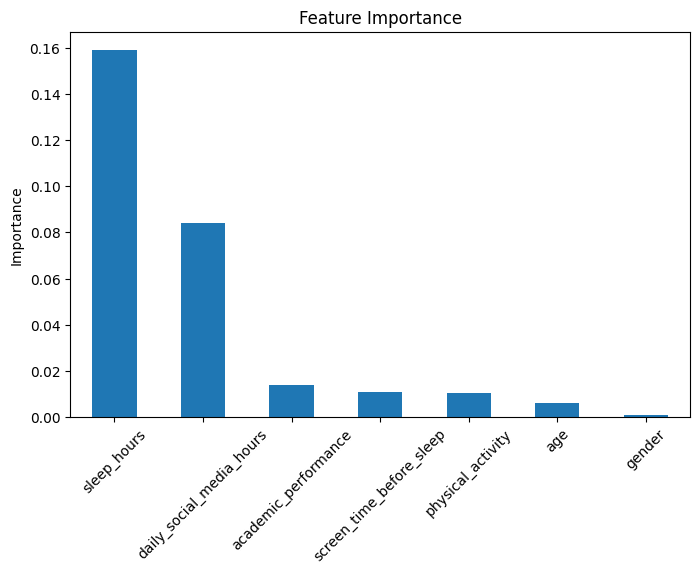

In [13]:
feat_imp = pd.Series(
    rf.feature_importances_,
    index=df.drop(columns=['depression_label']).columns
).head(7)
feat_imp = feat_imp.sort_values(ascending=False)

feat_imp.plot(kind='bar', figsize=(8,5))
plt.title("Feature Importance")
plt.ylabel("Importance")
plt.xticks(rotation=45)
plt.show()

In [14]:
pickle.dump(lr, open("../models/best_model.pkl", "wb"))
pickle.dump(scaler, open("../models/scaler.pkl", "wb"))
print("Model Saved.")

Model Saved.


# SQL

In [16]:
import sqlite3

conn = sqlite3.connect("../data/database/mental_health.db")
print("Connected.")

Connected.


In [17]:
df = pd.read_csv("../data/cleaned/merged_data.csv")
teen = pd.read_csv("../data/cleaned/teen_mental_health_cleaned.csv")
sm = pd.read_csv("../data/cleaned/social_media_cleaned.csv")

df.to_sql("merged_data", conn, if_exists="replace", index=False)
teen.to_sql("teen_mental_health", conn, if_exists="replace", index=False)
sm.to_sql("social_media", conn, if_exists="replace", index=False)

print("Tables Created.")

Tables Created.


In [24]:
df.head(4)

,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,risk_score,addiction_index,poor_sleep,high_usage
0,14,1,7,7.4,2.9,3.01,1.5,1,2,2,1,0,2.36,4.57,0,1
1,19,0,1,8.0,2.9,3.22,0.8,0,8,1,10,0,5.00,3.37,0,0
2,17,0,1,7.6,0.5,3.92,0.0,0,2,4,2,0,2.54,1.05,0,0
3,15,1,7,6.9,1.6,3.48,0.8,2,1,7,9,0,5.21,5.78,0,1


In [25]:
teen.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,1,7,1,7.4,2.9,3.01,1.5,1,2,2,1,0
1,19,0,1,2,8.0,2.9,3.22,0.8,0,8,1,10,0
2,17,0,1,1,7.6,0.5,3.92,0.0,0,2,4,2,0
3,15,1,7,2,6.9,1.6,3.48,0.8,2,1,7,9,0
4,15,0,4,0,4.9,3.0,2.37,1.4,2,3,5,2,0


In [26]:
sm.head()

,student_id,age,gender,academic_level,country,avg_daily_usage_hours,most_used_platform,affects_academic_performance,sleep_hours_per_night,mental_health_score,overall_impact
0,232,21,1,2,73,4,0,0,6.7,6.8,1
1,564,23,0,2,73,1,4,0,8.6,7.6,2
2,788,22,1,0,18,4,1,0,6.7,7.0,1
3,686,18,1,2,73,7,5,1,5.4,5.3,0
4,608,24,0,1,73,7,0,1,5.0,4.4,0


In [19]:
# Query 1: Depression Count
q1 = pd.read_sql_query("""
    SELECT depression_label, COUNT(*) as count
    FROM merged_data
    GROUP BY depression_label
""", conn)
print(q1)

   depression_label  count
0                 0   1200
1                 1     31


In [20]:
# Query 2: Avg Usage by Gender
q2 = pd.read_sql_query("""
    SELECT gender, ROUND(AVG(daily_social_media_hours), 2) as avg_usage
    FROM merged_data
    GROUP BY gender
""", conn)
print(q2)

   gender  avg_usage
0       0       4.13
1       1       4.12


In [21]:
# Query 3: High Risk Users
q3 = pd.read_sql_query("""
    SELECT COUNT(*) as high_risk_users
    FROM merged_data
    WHERE risk_score > 7
""", conn)
print(q3)

   high_risk_users
0              135


In [ ]:
# Query 4: Avg Sleep by Depression
q4 = pd.read_sql_query("""
    SELECT depression_label, ROUND(AVG(sleep_hours), 2) as avg_sleep
    FROM merged_data
    GROUP BY depression_label
""", conn)
print(q4)

   depression_label  avg_sleep
0                 0       6.49
1                 1       4.76


In [23]:
# Query 5: High Addiction Users
q5 = pd.read_sql_query("""
    SELECT COUNT(*) as high_addiction
    FROM merged_data
    WHERE addiction_index > 6
""", conn)
print(q5)

   high_addiction
0              23


In [27]:
conn.close()
print("SQL Testing Done")

SQL Testing Done
